In [1]:
# Week 4 - Logistic Regression + Feature Scaling
# Capstone project dataset

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# load the dataset
data = pd.read_csv("hypertension_dataset.csv")

# quick check of the data
data.head()

,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,...,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230,160,79,Never,27.9,Low,Yes,...,6.1,80,100,75,72,179,Female,Primary,Unemployed,High
1,Spain,34,36.2,201,120,84,Never,27.5,High,Yes,...,9.8,56,77,47,90,113,Male,Secondary,Unemployed,High
2,Indonesia,73,18.2,173,156,60,Current,1.8,High,Yes,...,5.2,75,162,56,81,101,Male,Primary,Employed,Low
3,Canada,60,20.3,183,122,94,Never,11.6,Moderate,Yes,...,7.5,71,164,93,94,199,Female,Secondary,Retired,High
4,France,73,21.8,296,91,97,Never,29.1,Moderate,Yes,...,5.0,52,108,74,226,157,Female,Primary,Employed,High


In [3]:
X = data.drop(columns=['Hypertension'])
y = data['Hypertension']

In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# pick numeric columns only
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled  = scaler.transform(X_test[num_cols])

# if you want DataFrames
import pandas as pd
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=num_cols, index=X_test.index)

In [13]:
# logistic regression model
logreg = LogisticRegression(max_iter=1000)  # added max_iter so it doesn’t get stuck
logreg.fit(X_train_scaled, y_train)

# predictions
y_pred = logreg.predict(X_test_scaled)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7174329228219561
Confusion Matrix:
 [[25108     0]
 [ 9889     0]]
Classification Report:
               precision    recall  f1-score   support

        High       0.72      1.00      0.84     25108
         Low       0.00      0.00      0.00      9889

    accuracy                           0.72     34997
   macro avg       0.36      0.50      0.42     34997
weighted avg       0.51      0.72      0.60     34997



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [18]:
try:
    feature_names = num_cols 
except NameError:
    feature_names = X_train.select_dtypes(include=[np.number]).columns.tolist()

# get coefficients
coefs = logreg.coef_.ravel()  # for binary classification this will be shape (n_features,)
if coefs.shape[0] != len(feature_names):
    raise ValueError(f"length mismatch: {len(feature_names)} feature names vs {coefs.shape[0]} coefficients")

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs
}).assign(Abs_Coefficient=lambda df: df['Coefficient'].abs()) \
  .sort_values(by="Abs_Coefficient", ascending=False) \
  .drop(columns="Abs_Coefficient")

print(coef_df)

           Feature  Coefficient
2      Cholesterol     0.009943
10             LDL     0.007866
0              Age     0.006015
12   Triglycerides    -0.004832
3      Systolic_BP     0.004721
4     Diastolic_BP    -0.004559
11             HDL    -0.004542
13         Glucose    -0.003244
6     Stress_Level     0.002436
1              BMI     0.001994
9       Heart_Rate    -0.001781
5   Alcohol_Intake     0.001385
8   Sleep_Duration     0.000921
7      Salt_Intake    -0.000603


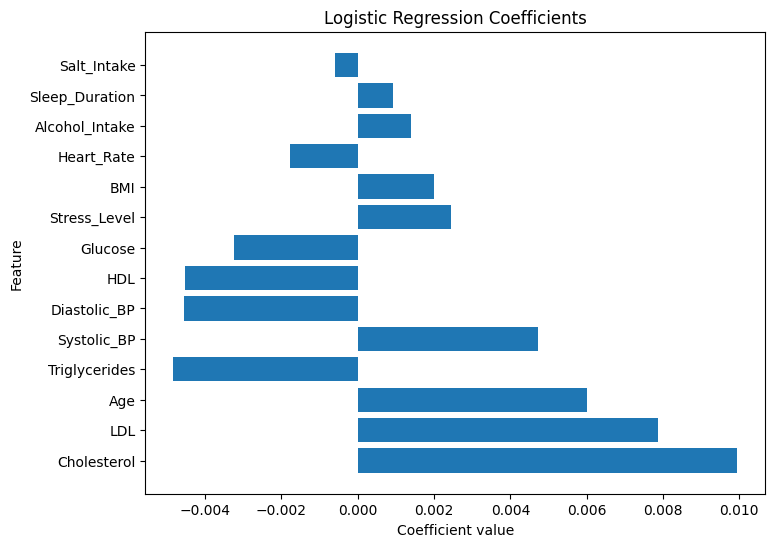

In [17]:
# plot coefficients to see which features matter most
plt.figure(figsize=(8,6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients")
plt.show()